Open-loop eigenvalues:   [ 5.71839138 -5.71839138]
Controllability rank:    2 / 2
LQR gain K:              [[-7.84499244 -2.31366045]]
Closed-loop eigenvalues: [ -3.17047862 -99.65887454]


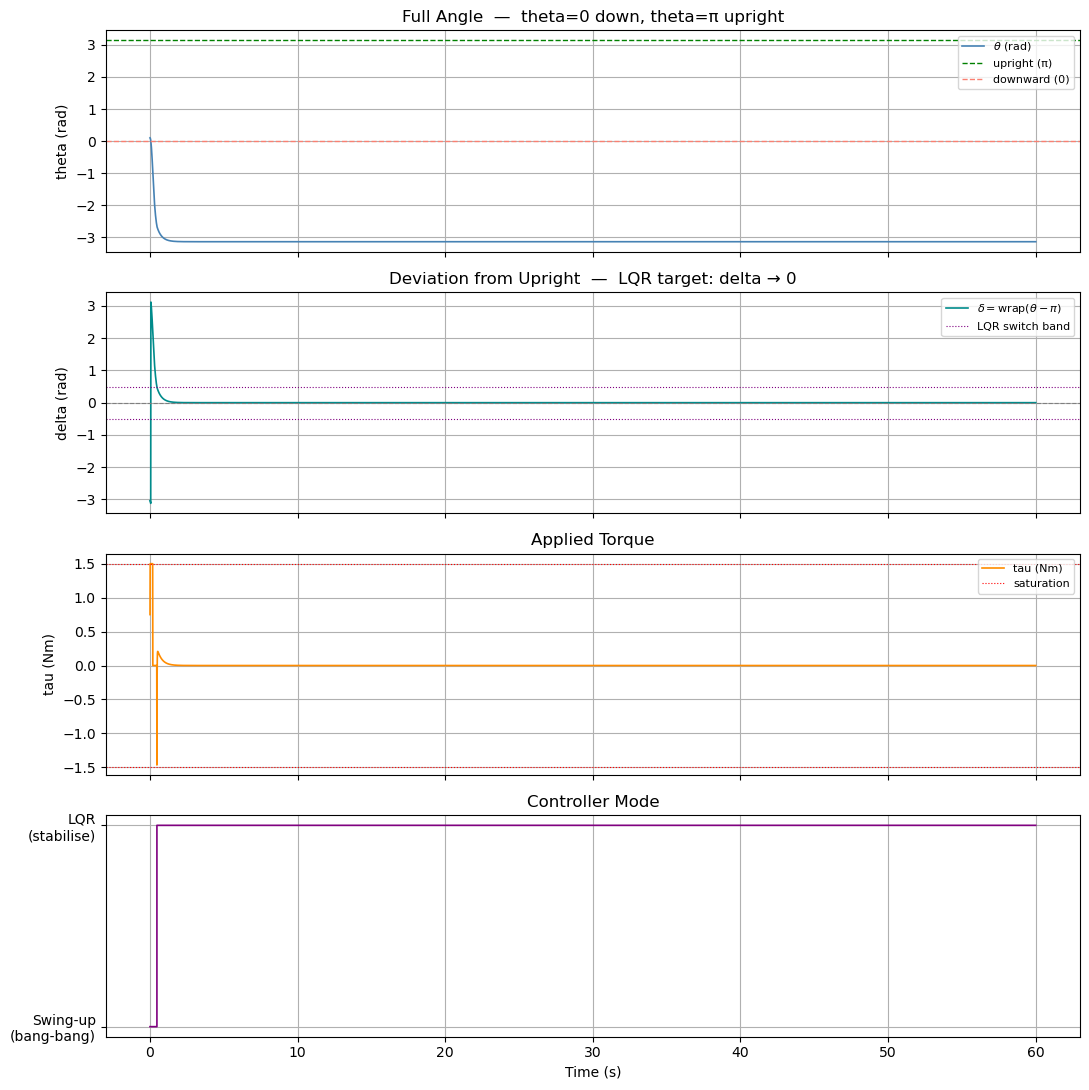


--- Final State ---
theta:      -3.1416 rad  (target π = 3.1416)
delta:      0.0000 rad  (target 0)
theta_dot:  -0.0000 rad/s (target 0)
Max torque: 1.5000 Nm
Time in LQR mode: 99.2%


In [16]:
"""
=============================================================
REACTION-WHEEL INVERTED PENDULUM — v5
Theodore Price-Parsons
=============================================================
Bang-bang swing-up (sign-of-velocity) + LQR stabilisation.

CONVENTION: theta=0 down, theta=pi upright (target).
EOM: theta_ddot = -(g/l)*sin(theta) - (b/(m*l^2))*theta_dot
                  - (2/(m*l^2))*tau
=============================================================
"""

import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import control

warnings.filterwarnings("ignore", category=DeprecationWarning)

# -------------------------------------------------------
# Physical Parameters
# -------------------------------------------------------
m   = 0.5      # kg
l   = 0.3      # m
Iw  = 0.002    # kg m^2
g   = 9.81     # m/s^2
b   = 0.03     # kg/s  viscous damping

# -------------------------------------------------------
# Linearized System (2-state, around upright)
# -------------------------------------------------------
A = np.array([
    [0,    1],
    [g/l,  0]
])

B = np.array([
    [0              ],
    [-2 / (m * l**2)]
])

eig_open = np.linalg.eigvals(A)
C_mat    = np.hstack([B, A @ B])
rank     = np.linalg.matrix_rank(C_mat)
print(f"Open-loop eigenvalues:   {np.real(eig_open)}")
print(f"Controllability rank:    {rank} / 2")

# -------------------------------------------------------
# LQR Design
# -------------------------------------------------------
Q = np.diag([50.0, 5.0])
R = np.array([[1.0]])

K, _, eig_cl = control.lqr(A, B, Q, R)
print(f"LQR gain K:              {K}")
print(f"Closed-loop eigenvalues: {np.real(eig_cl)}")

# -------------------------------------------------------
# Torque Limits & Switching Thresholds
# -------------------------------------------------------
u_max        = 1.5
u_min        = -u_max
delta_sw     = 0.5
delta_dot_sw = 4.0

# -------------------------------------------------------
# Helpers
# -------------------------------------------------------
def wrap(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

def compute_tau(theta, theta_dot):
    delta  = wrap(theta - np.pi)
    E      = 0.5 * m * l**2 * theta_dot**2 - m * g * l * np.cos(theta)
    E_star = m * g * l

    if E < E_star:
        tau_su = -u_max * np.sign(theta_dot) if abs(theta_dot) > 1e-6 else u_max * 0.5
    else:
        tau_su = 0.0

    tau_lqr      = -(K @ np.array([delta, theta_dot])).item()
    near_upright = abs(delta) < delta_sw and abs(theta_dot) < delta_dot_sw
    tau          = tau_lqr if near_upright else tau_su

    return np.clip(tau, u_min, u_max), near_upright

# -------------------------------------------------------
# Closed-Loop Dynamics
# -------------------------------------------------------
def closed_loop(t, x):
    theta, theta_dot, phi_dot = x
    tau, _ = compute_tau(theta, theta_dot)
    theta_ddot = (-(g / l) * np.sin(theta)
                  - (b / (m * l**2)) * theta_dot
                  - (2 / (m * l**2)) * tau)
    phi_ddot   = ((tau / Iw)
                  + (g / l) * np.sin(theta)
                  + (2 / (m * l**2)) * tau)
    return [theta_dot, theta_ddot, phi_ddot]

# -------------------------------------------------------
# Simulation
# -------------------------------------------------------
x0     = np.array([0.1, 0.0, 0.0])
t_span = (0, 60)
t_eval = np.linspace(*t_span, 5000)

sol = solve_ivp(closed_loop, t_span, x0, t_eval=t_eval,
                method='RK45', rtol=1e-6, atol=1e-8)

theta_sol     = sol.y[0]
theta_dot_sol = sol.y[1]
delta_sol     = wrap(theta_sol - np.pi)

tau_hist  = np.zeros(len(sol.t))
mode_hist = np.zeros(len(sol.t))
for i in range(len(sol.t)):
    tau_hist[i], near = compute_tau(theta_sol[i], theta_dot_sol[i])
    mode_hist[i]      = 1.0 if near else 0.0

# -------------------------------------------------------
# Sanity check: free pendulum
# -------------------------------------------------------
sol_free = solve_ivp(
    lambda t, x: [x[1], -(g / l) * np.sin(x[0]), 0.0],
    t_span, [0.3, 0.0, 0.0], t_eval=t_eval,
    method='RK45', rtol=1e-6, atol=1e-8
)

# -------------------------------------------------------
# Main Plots
# -------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)

axes[0].plot(sol.t, theta_sol, color='steelblue', lw=1.2, label=r'$\theta$ (rad)')
axes[0].axhline(np.pi, color='green',  ls='--', lw=1.0, label='upright (π)')
axes[0].axhline(0,     color='salmon', ls='--', lw=1.0, label='downward (0)')
axes[0].set_ylabel("theta (rad)"); axes[0].legend(fontsize=8); axes[0].grid(True)
axes[0].set_title("Full Angle  —  theta=0 down, theta=π upright")

axes[1].plot(sol.t, delta_sol, color='darkcyan', lw=1.2, label=r'$\delta = \mathrm{wrap}(\theta - \pi)$')
axes[1].axhline( 0,        color='gray',   ls='--', lw=0.8)
axes[1].axhline( delta_sw, color='purple', ls=':',  lw=0.8, label='LQR switch band')
axes[1].axhline(-delta_sw, color='purple', ls=':',  lw=0.8)
axes[1].set_ylabel("delta (rad)"); axes[1].legend(fontsize=8); axes[1].grid(True)
axes[1].set_title("Deviation from Upright  —  LQR target: delta → 0")

axes[2].plot(sol.t, tau_hist, color='darkorange', lw=1.2, label='tau (Nm)')
axes[2].axhline( u_max, color='red', ls=':', lw=0.8, label='saturation')
axes[2].axhline(-u_max, color='red', ls=':', lw=0.8)
axes[2].set_ylabel("tau (Nm)"); axes[2].legend(fontsize=8); axes[2].grid(True)
axes[2].set_title("Applied Torque")

axes[3].plot(sol.t, mode_hist, color='purple', drawstyle='steps-post', lw=1.2)
axes[3].set_yticks([0, 1])
axes[3].set_yticklabels(['Swing-up\n(bang-bang)', 'LQR\n(stabilise)'])
axes[3].set_xlabel("Time (s)"); axes[3].set_title("Controller Mode"); axes[3].grid(True)

plt.tight_layout()
plt.savefig("pendulum_v5.png", dpi=150)
plt.show()


# -------------------------------------------------------
# Terminal Report
# -------------------------------------------------------
print(f"\n--- Final State ---")
print(f"theta:      {theta_sol[-1]:.4f} rad  (target π = {np.pi:.4f})")
print(f"delta:      {delta_sol[-1]:.4f} rad  (target 0)")
print(f"theta_dot:  {theta_dot_sol[-1]:.4f} rad/s (target 0)")
print(f"Max torque: {np.max(np.abs(tau_hist)):.4f} Nm")
print(f"Time in LQR mode: {np.sum(mode_hist)/len(mode_hist)*100:.1f}%")

In [2]:
pip install control

  Using cached control-0.10.2-py3-none-any.whl.metadata (7.6 kB)
Using cached control-0.10.2-py3-none-any.whl (578 kB)
Note: you may need to restart the kernel to use updated packages.
